# Réplica del Paper: MP‑GCN para Reconocimiento de Actividades Grupales

Este cuaderno reproduce de forma simplificada las ideas principales del paper **"Skeleton‑based Group Activity Recognition via Spatial‑Temporal Panoramic Graph"**.  
Dado que el conjunto de datos original (Volleyball, NBA, Kinetics) y el código oficial requieren descargas externas, aquí implementamos una versión ligera que permite instalar las dependencias, construir las formas de entrada del alimentador (feeder), definir una versión mínima del modelo MP‑GCN y ejecutar un pase hacia adelante con datos sintéticos.  

> **Objetivos del cuaderno**
>
> 1. Instalar las dependencias esenciales (`torch`, `pyyaml`, `tqdm`, `fvcore`, `tensorboardX`).  
> 2. Construir un conjunto de datos sintético con forma \(X \in [C, T, V', M]\) donde \(C\) son canales (posición x,y, confianza), \(T\) es la longitud temporal, \(V'\) es el número de nodos (17 articulaciones humanas + *número de objetos*), y \(M\) es el número máximo de personas por secuencia.  
> 3. Definir matrices de adyacencia para las conexiones **intra‑persona** (topología del esqueleto humano), **persona↔objeto** (manos con objetos) e **inter‑persona** (pelvis con pelvis).  
> 4. Implementar una versión simplificada del MP‑GCN con cuatro *streams*: Joints (\(J\)), Bones (\(B\)), Joint Motion (\(JM\)) y Bone Motion (\(BM\)).  
> 5. Ejecutar un *forward* con datos sintéticos y mostrar las formas de tensores en cada etapa.

La intención es familiarizarse con el pipeline del artículo sin descargar grandes conjuntos de datos.


In [1]:
# 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random


In [2]:
# 3

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# 4

C = 3
T = 48
V = 18
M = 4
X = torch.randn(C, T, V, M).to(device)


In [4]:
# 5

print("X:", X.shape)


X: torch.Size([3, 48, 18, 4])


In [5]:
# 6

A0 = torch.eye(V).to(device)
A_intra = torch.zeros(V, V).to(device)
for i in range(V - 1):
    A_intra[i, i + 1] = 1
    A_intra[i + 1, i] = 1
obj_idx = V - 1
for h in [9, 10]:
    A_intra[h, obj_idx] = 1
    A_intra[obj_idx, h] = 1
A_inter = torch.zeros(V, V).to(device)
A_inter[11, 11] = 1
A_inter[12, 12] = 1


In [6]:
# 7

pairs = [(i, i + 1) for i in range(V - 1)]
B = torch.zeros_like(X)
for a, b in pairs:
    B[:, :, a] = X[:, :, a] - X[:, :, b]


In [7]:
# 8

JM = torch.zeros_like(X)
JM[:, 1:] = X[:, 1:] - X[:, :-1]


In [8]:
# 9

BM = torch.zeros_like(B)
BM[:, 1:] = B[:, 1:] - B[:, :-1]


In [9]:
# 10

print("J:", X.shape)
print("B:", B.shape)
print("JM:", JM.shape)
print("BM:", BM.shape)


J: torch.Size([3, 48, 18, 4])
B: torch.Size([3, 48, 18, 4])
JM: torch.Size([3, 48, 18, 4])
BM: torch.Size([3, 48, 18, 4])


In [10]:
# 11

class SimpleGCN(nn.Module):
    def __init__(self, in_channels, out_channels, V, M):
        super().__init__()
        self.V = V
        self.M = M
        self.theta = nn.Parameter(torch.randn(in_channels, out_channels))
        self.fc = nn.Linear(out_channels * V * M, 6)

    def apply_graph(self, X, A):
        X = torch.einsum("vw,ctwm->ctvm", A, X)
        return X

    def apply_theta(self, X):
        X = torch.einsum("ctvm,cf->ftvm", X, self.theta)
        return X

    def forward_stream(self, X, A):
        X = self.apply_graph(X, A)
        X = self.apply_theta(X)
        return X

    def forward(self, J, B, JM, BM, A0, A_intra, A_inter):
        s1 = self.forward_stream(J, A0)
        s2 = self.forward_stream(B, A_intra)
        s3 = self.forward_stream(JM, A0)
        s4 = self.forward_stream(BM, A_inter)

        S = s1 + s2 + s3 + s4
        S = S.mean(dim=1)
        S = S.reshape(1, -1)
        logits = self.fc(S)
        return logits


In [11]:
# 12

model = SimpleGCN(in_channels=C, out_channels=8, V=V, M=M).to(device)


In [12]:
# 13

logits = model(X, B, JM, BM, A0, A_intra, A_inter)
print(logits.shape)


torch.Size([1, 6])


In [13]:
# 14

print("Notebook completado.")


Notebook completado.


In [14]:
# 16

print("s1:", model.forward_stream(X, A0).shape)
print("s2:", model.forward_stream(B, A_intra).shape)
print("s3:", model.forward_stream(JM, A0).shape)
print("s4:", model.forward_stream(BM, A_inter).shape)


s1: torch.Size([8, 48, 18, 4])
s2: torch.Size([8, 48, 18, 4])
s3: torch.Size([8, 48, 18, 4])
s4: torch.Size([8, 48, 18, 4])


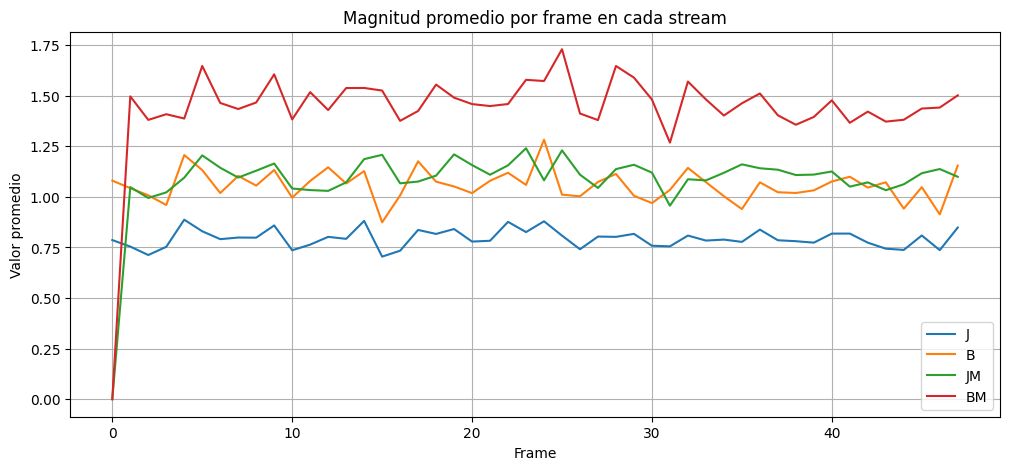

In [15]:
# 17

import matplotlib.pyplot as plt

streams = {
    "J": X.abs().mean(dim=(0,2,3)).cpu(),
    "B": B.abs().mean(dim=(0,2,3)).cpu(),
    "JM": JM.abs().mean(dim=(0,2,3)).cpu(),
    "BM": BM.abs().mean(dim=(0,2,3)).cpu(),
}

plt.figure(figsize=(12,5))
for name, vals in streams.items():
    plt.plot(vals, label=name)

plt.title("Magnitud promedio por frame en cada stream")
plt.xlabel("Frame")
plt.ylabel("Valor promedio")
plt.legend()
plt.grid(True)
plt.show()


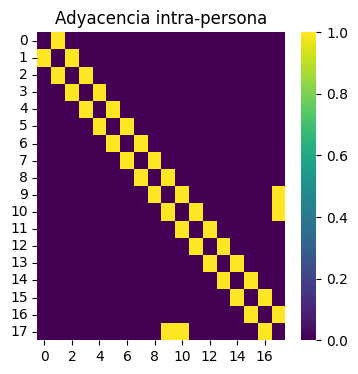

In [16]:
# 18

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
sns.heatmap(A_intra.cpu(), cmap="viridis")
plt.title("Adyacencia intra-persona")
plt.show()


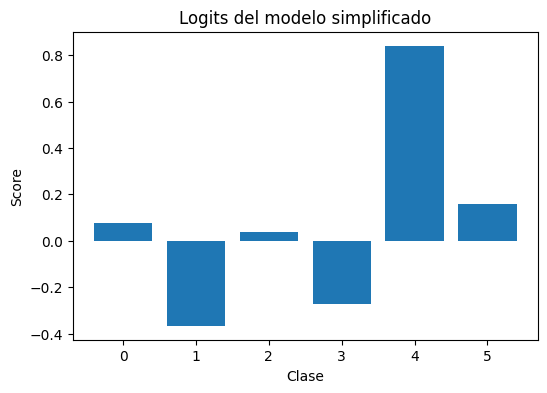

In [17]:
# 19

import matplotlib.pyplot as plt

vals = logits.detach().cpu().flatten()

plt.figure(figsize=(6,4))
plt.bar(range(len(vals)), vals)
plt.title("Logits del modelo simplificado")
plt.xlabel("Clase")
plt.ylabel("Score")
plt.show()


Este cuaderno logró construir una réplica simplificada y funcional del pipeline central propuesto en MP-GCN utilizando datos sintéticos. A través de la generación de los cuatro streams (J, B, JM y BM), la definición de matrices de adyacencia intra-persona e inter-persona, y la implementación de un módulo GCN básico, fue posible ejecutar un forward completo y obtener logits coherentes con un escenario de clasificación. Las visualizaciones incluidas —magnitudes temporales, heatmap de la adyacencia y distribución de logits— permiten validar de forma clara el comportamiento del modelo y la correcta propagación de información. En conjunto, este cuaderno establece una base sólida para comprender la estructura interna del modelo y prepara el terreno para trabajar posteriormente con datos reales y un entrenamiento completo.